In [1]:
#%matplotlib ipympl
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from time import gmtime, strftime
import os

### Normal Form Games
First, we're going to define a normal form game with two agents, an expected reward matrix and gradients for each. This allows for a pretty straightforward creation of games like Rock-Paper-Scissors, Prisoner's Dilemma, etc.

In [2]:
class NormalFormGame:
    """
    Two-agent normal-form game.
    R1, R2: (n_actions_1, n_actions_2) reward matrices.
    """
    def __init__(self, name: str, R1: np.ndarray, R2: np.ndarray):
        self.name = name
        self.R1 = np.array(R1, dtype=float)
        self.R2 = np.array(R2, dtype=float)
        self.n1, self.n2 = R1.shape

    def expected_rewards(self, p: np.ndarray, q: np.ndarray):
        """Expected rewards given mixed policies p (agent1) and q (agent2)."""
        u1 = p @ self.R1 @ q
        u2 = p @ self.R2 @ q
        return u1, u2

    def grad_u1(self, q: np.ndarray) -> np.ndarray:
        """Gradient of U1 w.r.t. p  (= R1 q)."""
        return self.R1 @ q

    def grad_u2(self, p: np.ndarray) -> np.ndarray:
        """Gradient of U2 w.r.t. q  (= R2^T p)."""
        return self.R2.T @ p


def make_rps():
    R1 = np.array([[0, -1, 1], [1, 0, -1], [-1, 1, 0]], dtype=float)
    return NormalFormGame("Rock-Paper-Scissors", R1, -R1)

def make_prisoners_dilemma():
    R1 = np.array([[-1, -5], [0, -3]], dtype=float)
    R2 = np.array([[-1, 0], [-5, -3]], dtype=float)
    return NormalFormGame("Prisoner's Dilemma", R1, R2)

def make_coordination():
    R = np.array([[10, 0], [0, 10]], dtype=float)
    return NormalFormGame("Coordination", R, R)

def make_stag_hunt():
    R = np.array([[10, 0], [3, 3]], dtype=float)
    return NormalFormGame("Stag Hunt", R, R)

def make_chicken():
    R = np.array([[0,7], [2, 6]], dtype=float)
    return NormalFormGame("Chicken", R, R.T)

It should be noted right from the start that only the matrices used in RPS have imaginary eigenvalues, which means - as we will see below - that interesting orbit dynamics of learned policies are only observed here. For the other games, agents learning them will almost immediately converge to choosing one option with 100% probability.

### Policy Learning Algorithms

In [ ]:
def simplex_project(v: np.ndarray) -> np.ndarray:
    """Project a vector onto the probability simplex."""
    n = len(v)
    u = np.sort(v)[::-1]
    cssv = np.cumsum(u)
    rho = np.nonzero(u * np.arange(1, n + 1) > (cssv - 1))[0][-1]
    theta = (cssv[rho] - 1.0) / (rho + 1.0)
    result = np.maximum(v - theta, 0)
    return result


def run_iga(game: NormalFormGame, T: int = 8000, eta: float = 0.02,
            p0=None, q0=None, rng=None) -> np.ndarray:
    """
    Infinitesimal Gradient Ascent.
    Each agent ascends its own expected-return gradient w.r.t. its policy.
    Returns array of shape (T, n1-1 + n2-1): reduced joint-policy trajectory
    (we drop the last probability of each agent since policies sum to 1).
    """
    if rng is None:
        rng = np.random.default_rng(0)
    p = rng.dirichlet(np.ones(game.n1)) if p0 is None else np.array(p0)
    q = rng.dirichlet(np.ones(game.n2)) if q0 is None else np.array(q0)
    traj = []
    for _ in range(T):
        traj.append(np.concatenate([p[:-1], q[:-1]]))
        gp = game.grad_u1(q)
        gq = game.grad_u2(p)
        p = simplex_project(p + eta * gp)
        q = simplex_project(q + eta * gq)
    return np.array(traj)


def run_wolf_phc(game: NormalFormGame, T: int = 8000,
                 eta_win: float = 0.005, eta_lose: float = 0.03,
                 p0=None, q0=None, rng=None) -> np.ndarray:
    """
    WoLF-PHC: use a small learning rate when winning, large when losing.
    'Winning' means current return >= return under average policy vs opponent avg.
    """
    if rng is None:
        rng = np.random.default_rng(1)
    p = rng.dirichlet(np.ones(game.n1)) if p0 is None else np.array(p0)
    q = rng.dirichlet(np.ones(game.n2)) if q0 is None else np.array(q0)
    p_avg = p.copy()
    q_avg = q.copy()
    traj = []
    for t in range(1, T + 1):
        traj.append(np.concatenate([p[:-1], q[:-1]]))

        u1_cur, u2_cur = game.expected_rewards(p, q)
        u1_avg, _ = game.expected_rewards(p_avg, q)
        _, u2_avg = game.expected_rewards(p, q_avg)

        eta1 = eta_win if u1_cur >= u1_avg else eta_lose
        eta2 = eta_win if u2_cur >= u2_avg else eta_lose

        gp = game.grad_u1(q)
        gq = game.grad_u2(p)
        p = simplex_project(p + eta1 * gp)
        q = simplex_project(q + eta2 * gq)

        alpha = 1.0 / t
        p_avg = p_avg + alpha * (p - p_avg)
        q_avg = (1 - alpha) * q_avg + alpha * q

    return np.array(traj)

def run_regret_matching(game: NormalFormGame, T: int = 8000,
                        p0=None, q0=None, rng=None) -> np.ndarray:
    """
    Unconditional regret matching.
    Each agent tracks cumulative regret per action and plays proportional
    to positive regrets (uniform if all regrets are non-positive).
    """
    if rng is None:
        rng = np.random.default_rng(2)
    cum_r1 = np.zeros(game.n1)
    cum_r2 = np.zeros(game.n2)
    p = rng.dirichlet(np.ones(game.n1)) if p0 is None else np.array(p0)
    q = rng.dirichlet(np.ones(game.n2)) if q0 is None else np.array(q0)
    traj = []
    for _ in range(T):
        traj.append(np.concatenate([p[:-1], q[:-1]]))
        # Sample actions
        a1 = rng.choice(game.n1, p=p)
        a2 = rng.choice(game.n2, p=q)
        r1 = game.R1[a1, a2]
        r2 = game.R2[a1, a2]
        # Counterfactual regrets
        cf1 = game.R1[:, a2] - r1
        cf2 = game.R2[a1, :] - r2
        cum_r1 += cf1
        cum_r2 += cf2
        # Update policies
        pos1 = np.maximum(cum_r1, 0)
        pos2 = np.maximum(cum_r2, 0)
        p = pos1 / pos1.sum() if pos1.sum() > 0 else np.ones(game.n1) / game.n1
        q = pos2 / pos2.sum() if pos2.sum() > 0 else np.ones(game.n2) / game.n2

    return np.array(traj)

These are going to be our classes for logically coupling games to the data (trajectories) we generate (both using learning algorithms and AL-RNNs):

In [4]:
class TrajectoryData:
    """
    Data bundling the trajectory generated from e.g. IGA and the model we trained on this data.
    """
    def __init__(self, algo_name: str, trajectory: np.ndarray):
        self.algo_name = algo_name
        self.trajectory = trajectory # Produced by policy learning algorithm
        self.model = None
        self.dataset = None # self.trajectory wrapped in TimeSeriesDataset
        self.generated_trajectory = None # Produced by the AL-RNN model
        self.timestamp = None

    def load_trajectory_from_file(path):
        loaded = np.load(path)
        self.trajectory = loaded

    def save_trajectory_to_file(path):
        np.save(path, self.trajectory)

class GameData:
    """
    Data bundling the games and trajectory data.
    """
    def __init__(self, game: NormalFormGame):
        self.game = game
        self.trajectory_data = None

gamesData = [
    GameData(make_rps()),
    GameData(make_chicken()),
    GameData(make_prisoners_dilemma()),
    GameData(make_coordination()),
    GameData(make_stag_hunt())
]

### Animation

In [5]:
def visualize_3D(fig, traj, title, position, time_range=None, animate=False):
    if time_range == None:
        time_range = range(0, traj.shape[0], 50)
    ax = fig.add_subplot(position, projection="3d")

    # Precompute z values
    p_third_option_a = 1 - traj[:, 0] - traj[:, 1]
    p_third_option_b = 1 - traj[:, 2] - traj[:, 3]

    # Define fixed colors
    color_a = "tab:blue"
    color_b = "tab:orange"

    # Initialize lines with fixed colors
    line_a, = ax.plot([], [], [], label="Agent A", color=color_a)
    line_b, = ax.plot([], [], [], label="Agent B", color=color_b)

    # Initialize dots with the same fixed colors
    dot_a, = ax.plot([], [], [], 'o', markersize=8, color=color_a)
    dot_b, = ax.plot([], [], [], 'o', markersize=8, color=color_b)

    ax.set_xlabel("P(Rock)")
    ax.set_ylabel("P(Paper)")
    ax.set_zlabel("P(Scissors)")
    ax.set_title(title)
    ax.legend()

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_zlim(0, 1)

    def update(frame):
        # Trajectory lines
        line_a.set_data(traj[:frame, 0], traj[:frame, 1])
        try:
            line_a.set_3d_properties(p_third_option_a[:frame])
        except:
            line_a.set_3d_properties(p_third_option_a[:frame])

        line_b.set_data(traj[:frame, 2], traj[:frame, 3])
        try:
            line_b.set_3d_properties(p_third_option_b[:frame])
        except:
            line_b.set_3d_properties(p_third_option_b[:frame])

        # Latest point (dot)
        if frame > 0:
            dot_a.set_data(traj[frame-1:frame, 0], traj[frame-1:frame, 1])
            dot_a.set_3d_properties(p_third_option_a[frame-1:frame])

            dot_b.set_data(traj[frame-1:frame, 2], traj[frame-1:frame, 3])
            dot_b.set_3d_properties(p_third_option_b[frame-1:frame])

        return line_a, line_b, dot_a, dot_b

    plt.tight_layout()
    
    if not animate:
        update(traj.shape[0])
        return None

    anim = FuncAnimation(
        fig,
        update,
        frames=time_range,
        interval=300,
        blit=False
    )
    return anim

def visualize_2D(fig, traj, title, position):
    ax = fig.add_subplot(position)

    # Define fixed colors
    color_a = "tab:blue"
    color_b = "tab:orange"

    #time_range = range(0, traj.shape[0])
    line_a, = ax.plot(traj[:, 0], label="Agent A", color=color_a)
    line_b, = ax.plot(traj[:, 1], label="Agent B", color=color_b)
    ax.set_xlabel("Time")
    ax.set_ylabel("P(Option1)")

    ax.set_title(title)
    ax.legend()

    plt.tight_layout()
    return fig

def timestamp():
    return strftime("%Y-%m-%d %H:%M:%S", gmtime())

def visualize_trajectories(gameData: GameData, visualize):
    print(gameData.game.name)
    fig = plt.figure(figsize=(10,6))
    iga = gameData.trajectory_data[0]
    wolf_phc = gameData.trajectory_data[1]
    regret_matching = gameData.trajectory_data[2]
    iga_anim = visualize(fig, iga.trajectory, iga.algo_name, 131)
    wolf_phc_anim = visualize(fig, wolf_phc.trajectory, wolf_phc.algo_name, 132)
    regret_matching_anim = visualize(fig, regret_matching.trajectory, regret_matching.algo_name, 133)
    plt.show()

As mentioned, we observe orbital dynamics for RPS:

In [6]:
def generate_trajectories(gameData):
    iga = TrajectoryData("Infitesimal Gradient Ascent", run_iga(gameData.game))
    wolf_phc = TrajectoryData("Wolf PHC", run_wolf_phc(gameData.game))
    regret_matching = TrajectoryData("Regret Matching", run_regret_matching(gameData.game))
    return [iga, wolf_phc, regret_matching]

Rock-Paper-Scissors


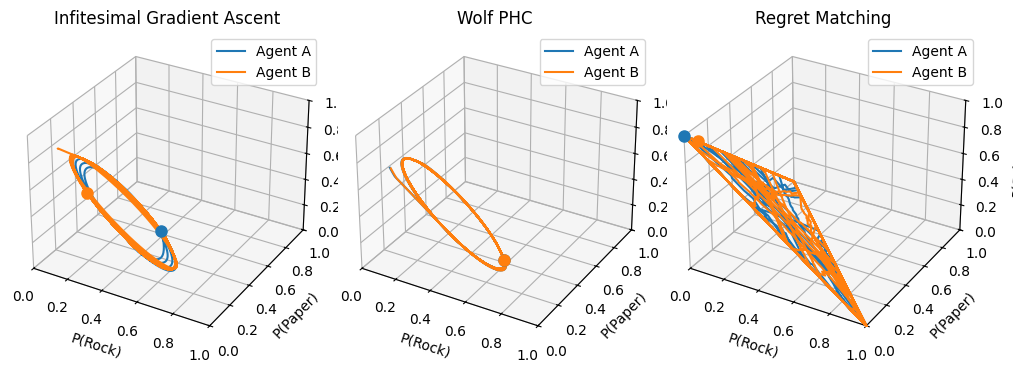

In [7]:
gamesData[0].trajectory_data = generate_trajectories(gamesData[0])
visualize_trajectories(gamesData[0], visualize_3D)

... but not for the other games:

Chicken


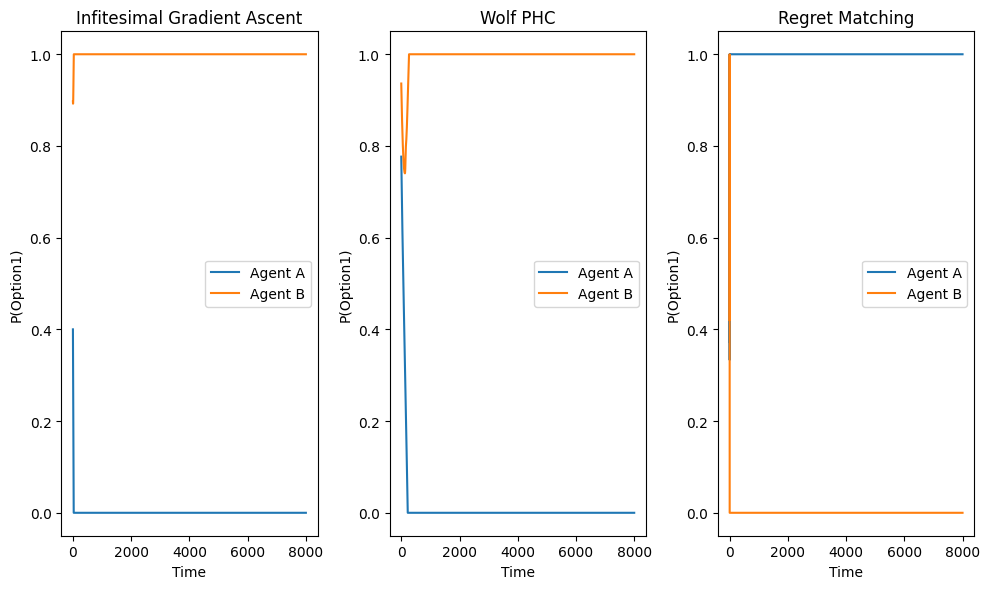

In [8]:
gamesData[1].trajectory_data = generate_trajectories(gamesData[1])
visualize_trajectories(gamesData[1], visualize_2D)

Prisoner's Dilemma


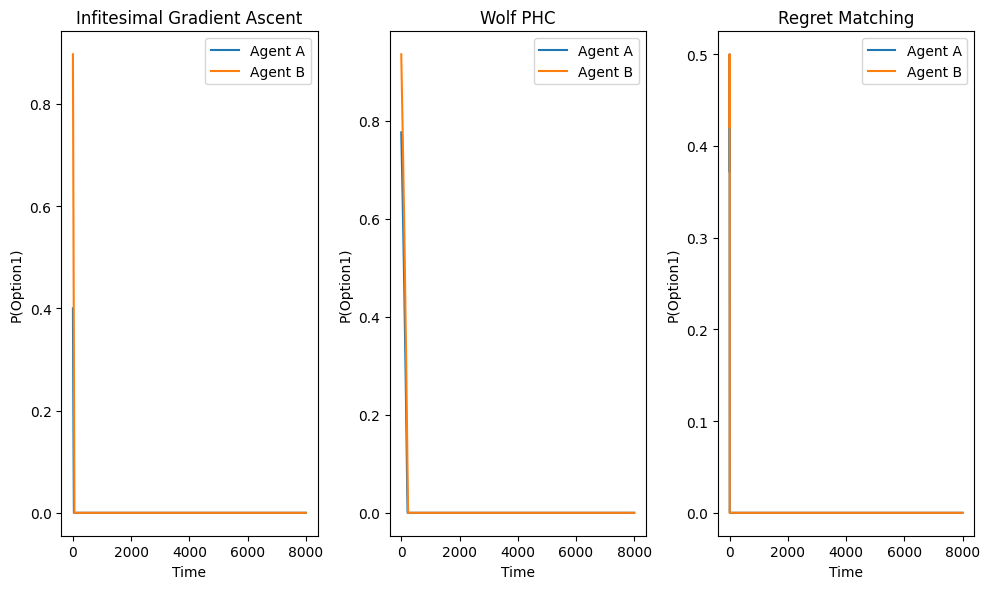

In [9]:
gamesData[2].trajectory_data = generate_trajectories(gamesData[2])
visualize_trajectories(gamesData[2], visualize_2D)

Coordination


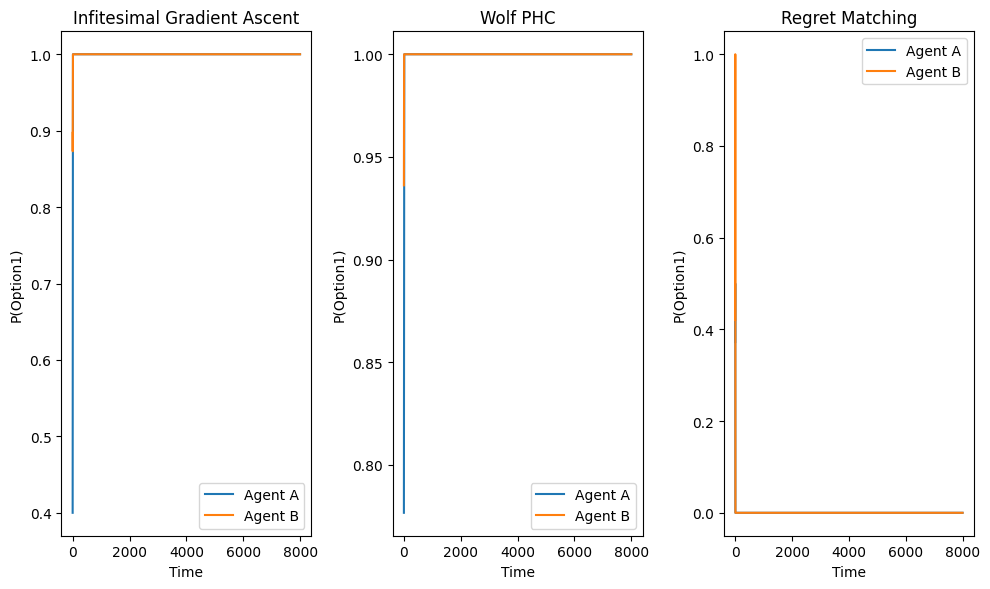

In [10]:
gamesData[3].trajectory_data = generate_trajectories(gamesData[3])
visualize_trajectories(gamesData[3], visualize_2D)

Stag Hunt


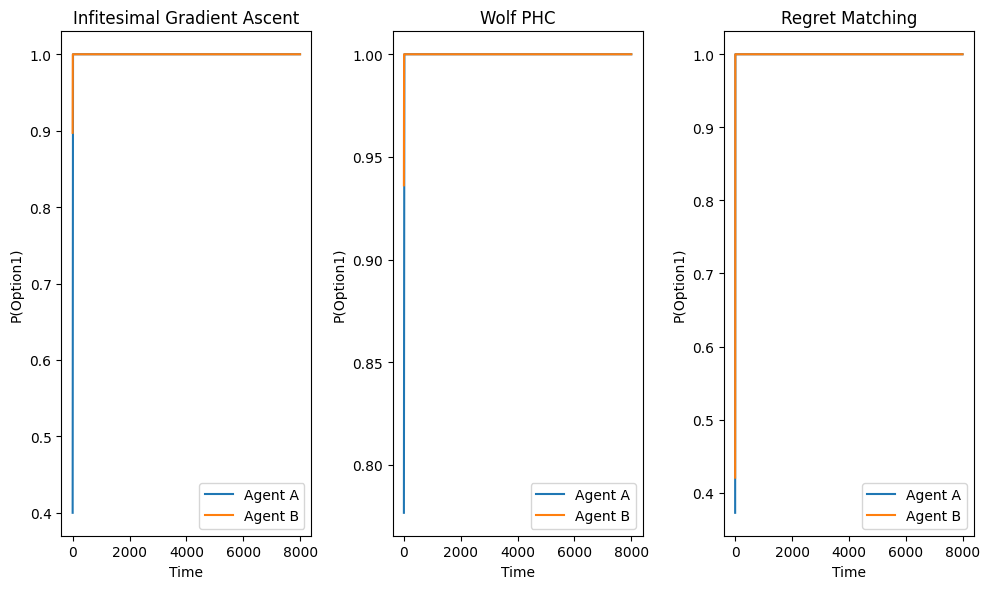

In [11]:
gamesData[4].trajectory_data = generate_trajectories(gamesData[4])
visualize_trajectories(gamesData[4], visualize_2D)

## AL-RNNs
We adapt the implementation of AL-RNNs as given by https://github.com/DurstewitzLab/ALRNN-DSR. I've added the Jacobian method (and may have slightly changed some parts of the code for our purposes):

In [12]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import optim
import math
from dataset import TimeSeriesDataset
import linear_region_functions as lrf
from metrics import state_space_divergence_binning, power_spectrum_error
import copy
from tqdm import trange

In [13]:
class AL_RNN(nn.Module):
    def __init__(self, M, P, N):
        super(AL_RNN, self).__init__()

        # Initialize model dimensions
        self.M = M
        self.P = P
        self.N = N   

        # Initialize model parameters A, W, h, B    
        self.A, self.W, self.h = self.initialize_AWh_random()
        self.B = self.init_uniform((self.N,self.M))
        
    def forward(self, z):
        # Make a copy of the input tensor to retain unactivated values
        z_unactivated=torch.clone(z)

        # Apply ReLU activation on the last P units
        z[:, -self.P:] = F.relu(z[:, -self.P:])

        # Compute the forward pass
        return self.A * z_unactivated + z @ self.W.t() + self.h

    @torch.no_grad()
    def jacobian(self, z):
        diag = torch.ones(self.M)
        diag[-self.P:] = torch.where(z[:,-self.P:] > 0.0, torch.Tensor([1.0]), torch.Tensor([0.0]))
        D = torch.diag(diag).detach()
        return torch.diag(self.A) + self.W @ D
    
    def initialize_AWh_random(self):
        #Randomly initialize A, W, h
        A = nn.Parameter(torch.diagonal(self.normalized_positive_definite(self.M),0)) # Create diagonal matrix A from normalized positive definite matrix
        W = nn.Parameter(torch.randn(self.M, self.M)*0.1) # Initialize weight matrix W with gaussian random numbers
        h = nn.Parameter(torch.zeros(self.M)) # Initialize bias vector h to zero
        return A, W, h
    
    
    def normalized_positive_definite(self,M):
        # Generate a normalized positive definite matrix
        R = np.random.randn(M, M).astype(np.float32)
        K = np.matmul(R.T, R) / M + np.eye(M)  # R'R ./ M + I
        eigenvalues = np.linalg.eigvals(K)
        lambda_max = np.max(np.abs(eigenvalues))
        return torch.tensor(K / lambda_max).float()
    
    
    def init_uniform(self, shape):
        # Initialize a tensor with a uniform distribution within range [-1/sqrt(M), 1/sqrt(M)]
        tensor = torch.empty(*shape)
        r = 1 / math.sqrt(shape[0])
        torch.nn.init.uniform_(tensor, -r, r)
        return nn.Parameter(tensor, requires_grad=True)


@torch.no_grad() # Disables gradient calculation to save memory and computation
def predict_free_sequence(model, x, T):
    # Predicts a sequence without updating model parameters
    b, N = x.size()

    Z = torch.empty(size=(T, b, model.M), device=x.device) # Initialize output tensor for the predicted sequence
    z = x @ model.B # Initialize first latent state
    z[:,0:N] = x

    # Predict sequence by passing previous state through the model
    for t in range(0, T):
        z = model(z)
        Z[t] = z
    return Z.permute(1, 0, 2)

def predict_sequence_using_gtf(model, x, alpha, n_interleave):
    # Predicts a sequence using teacher forcing (only for training)
    x_ = x.permute(1, 0, 2) # Permute input to shape (sequence_length, batch_size, feature_dim)
    T, b, dx = x_.size() # T: sequence length, b: batch size, dx: feature dimension
    Z = torch.empty(size=(T, b, model.M), device=x.device)
    z =  x_[0] @ model.B # Initialize first latent state
    z = teacher_force(z, x_[0], model, alpha=1) # Apply teacher forcing to the initial state

    # Generate sequence predictions
    for t in range(0, T):
        # Apply teacher forcing at regular intervals
        if (t % n_interleave == 0) and (t > 0):
            z = teacher_force(z, x_[t], model, alpha)
            
        # Update the latent state using the model
        z = model(z)
        Z[t] = z
    return Z.permute(1, 0, 2)

def teacher_force(z, x, model, alpha):
    # Teacher force the state z
    z[:, :model.N] = alpha * x + (1 - alpha) * z[:, :model.N]
    return z

## Training

We bundle relevant configuration parameters in the TrainConfig class and pass an instance to the training method given by DurstewitzLab:

In [14]:
class TrainConfig:
    def __init__(self):
        # Identity Teacher Forcing
        self.alpha=1
        #teacher forcing interval (readout units are forced every time steps)
        self.n_interleave=16

        # optimization
        self.num_epochs = 100
        self.batches_per_epoch=50
        self.ssi=20
        self.use_best_model=False
        self.animate=False
        self.name_for_anim="undefined"

def train_sh(model, dataset, optimizer, scheduler, loss_fn, config: TrainConfig):
    assert config.ssi < config.num_epochs
    model.train() # Set model to training mode
    model.float()
    best_model = copy.deepcopy(model) # Initialize best_model saver
    losses = []
    klx = []
    dh = []
    
    with trange(config.num_epochs, desc="Training Progress") as epochs:
        # Loop over batches in each epoch
        for e in epochs:
            epoch_losses = []

            for _ in range(config.batches_per_epoch):
                optimizer.zero_grad() # Reset gradients for the optimizer
                
                x, y, s = dataset.sample_batch() # Sample a batch of data (x: inputs, y: targets)
                z_hat = predict_sequence_using_gtf(model, x, config.alpha, config.n_interleave) # Predict sequence using teacher forcing
                loss = loss_fn(z_hat[:,:,:model.N], y) # Calculate loss                        
                loss.backward() # Backward pass
                optimizer.step()
                epoch_losses.append(loss.item())
        

            scheduler.step() # Adjust learning rate based on the scheduler
            
            # Compute and store average loss for the epoch
            average_epoch_loss = sum(epoch_losses) / len(epoch_losses)
            epochs.set_postfix(loss=average_epoch_loss)
            losses.append(average_epoch_loss)

            # Save dynamical systems performance metrics Dstsp and DH each #ssi(scalar saving interval) epochs
            if e % config.ssi == 0 or e == config.num_epochs-1:
                with torch.no_grad():
                    # 10000 was value for the original Lorentz63 dataset here, which for its 99500 timepoints is roughly 1/10th
                    # However, for general purposes, we have to adjust this value to the number of timepoints of our individual datasets
                    n_timesteps = 1000 #int(dataset.X.shape[0] / 10)
                    z_test = predict_free_sequence(model, dataset.X.clone().detach()[0:1,:], n_timesteps) # Predict sequence using teacher forcing
                    # Animate the sequence
                    if config.animate:
                        fig = plt.figure(figsize=(8, 6))
                        generated_anim = visualize_3D(fig, z_test[0,:,:], "Epoch " + str(e), 111, animate=True, time_range=range(0, n_timesteps, 50))
                        generated_anim.save("training/" + timestamp() + config.name_for_anim + "_epoch_" + str(e) + ".mp4", fps=25)
                        plt.show()
                    klx.append(state_space_divergence_binning(z_test[0,:,0:model.N], dataset.X.clone().detach())) # Calculate Dstsp
                    test_X = z_test[0,:,0:model.N]
                    test_X_gen = dataset.X.clone().detach()[0:n_timesteps,:]
                    dh.append(power_spectrum_error(test_X, test_X_gen)) # Calculate DH
                    
                    if torch.argmin(torch.tensor(klx)) + 1 == len(torch.tensor(klx)): # Check if current model is best according to Dstsp
                        best_model = copy.deepcopy(model) # Copy the best model

    if config.use_best_model: # If true the best model (according to Dstsp) during training is returned, else the one from the last epoch
        model.load_state_dict(best_model.state_dict())
    
    return [losses, klx, dh]

However, for our purposes, we would like to keep an additional eye on the dynamical system's attributes and log their evolution during training using the Logger class, and we visualize the tracked attribute with the subsequent visualization method:

In [15]:
import pandas as pd

class Logger():
    def __init__(self, model):
        self.model = model
        self.dstsp = None
        self.DH = None
        self.fixed_points = None
        self.max_evs = None
        self.max_lyapunov_exponent = None
        self.unique_regions = None
        self.frequencies = None # Timesteps in each used region
        self.path_to_log = None

    def create_log(self, timestamp):
        self.path_to_log = "models/" + timestamp + "-log.csv"
        header = "N,M,P,epoch,dstsp,dh,fixed_points,max_eigenvalues,max_lyapunov_exponent,unique_regions,frequencies\n"
        with open(self.path_to_log, "w") as file:
            file.write(header)

    def save_log(self, epoch):
        df = pd.DataFrame([{
            "N" : str(self.model.N),
            "M" : str(self.model.M),
            "P" : str(self.model.P),
            "epoch" : str(epoch),
            "dstsp" : str(self.dstsp),
            "dh" : str(self.DH),
            "fixed_points" : str(self.fixed_points.tolist()),
            "max_eigenvalues" : str(self.max_evs), #[torch_value.item() for torch_value in self.max_evs],
            "max_lyapunov_exponent" : str(self.max_lyapunov_exponent),
            "unique_regions" : str(self.unique_regions),
            "frequencies" : str(self.frequencies.tolist())
        }])
        df.to_csv(self.path_to_log, mode="a", index=False, header=False)


def visualize_training(path):
    df = pd.read_csv(path)
    df.fillna(0, inplace=True)
    fig, ax = plt.subplots(2,3, figsize=(10,6)) 
    epochs = df["epoch"]
    
    ax[0,0].plot(epochs, df["dstsp"])
    ax[0,0].set_ylabel("DSTSP")

    ax[0,1].plot(epochs, df["dh"])
    ax[0,1].set_ylabel("DH")

    ax[0,2].plot(epochs, df["max_lyapunov_exponent"])
    ax[0,2].set_ylabel("Max Lyapunov")

    df["fixed_points"] = df["fixed_points"]
    fixed_points = [eval(fp) for fp in df["fixed_points"].values]
    actual_fp = np.array([1/3, 1/3, 1/3, 1/3])
    fp_distances = []
    for fps in fixed_points:
        dist = [np.linalg.norm(fp[:4] - actual_fp) for fp in fps]
        fp_distances.append(min(dist)) # There tend to be multiple fixed points for each region, we are interested in the one resembling the actual action policy FP
    ax[1,0].plot(epochs, fp_distances)
    ax[1,0].set_ylabel("FP Distance")

    max_evs = [max(eval(ev)) for ev in df["max_eigenvalues"].values]
    ax[1,1].plot(epochs, max_evs)
    ax[1,1].set_ylabel("Max EV")

    max_time_spent_in_region = [max(eval(freq)) for freq in df["frequencies"].values]
    ax[1,2].plot(epochs, max_time_spent_in_region)
    ax[1,2].set_ylabel("Max Time")
    
    
    plt.tight_layout()
    plt.show()

... and implement some functions for calculating attributes of interest (taken from the Julia implementation of the same DurstewitzLab repository):

In [16]:
@torch.no_grad()
def max_lyapunov_exponent(model, generated_orbit, T, ons=1):
    # initialize
    z = torch.Tensor([generated_orbit[-1]])
    lyap = 0
    # initialize as Identity matrix
    Q = torch.eye(model.M)

    for t in range(T):
        z=model(z)
        J = model.jacobian(z)
        Q = J @ Q

        if (t % ons == 0):
            # reorthogonalize
            Q, R = torch.linalg.qr(Q)
            # accumulate lyapunov exponents
            lyap += torch.log(torch.abs(R[0, 0])).item()

    return lyap / T

def calc_FP(model, regions):
    z_fp = []
    stab = []

    for region in regions:
        diag = torch.ones(model.M)
        diag[-model.P:] = torch.tensor(region, dtype=torch.float32)
        D = torch.diag(diag).detach()

        A_diag = torch.diag(model.A.detach())
        W = model.W.detach()
        h = model.h.detach()
        fp = torch.linalg.inv(torch.eye(model.M) - A_diag - W @ D) @ h
        z_fp.append(fp)
        eigvals = torch.linalg.eigvals(A_diag + W @ D)
        stab.append(torch.max(torch.abs(eigvals)).item())

    z_fp = np.vstack(z_fp)
    return z_fp, stab

We thus have our
### Training + Logging method

In [17]:
def train_sh_and_log(model, dataset, optimizer, scheduler, loss_fn, config: TrainConfig, logger: Logger):
    assert config.ssi < config.num_epochs
    model.train() # Set model to training mode
    model.float()
    best_model = copy.deepcopy(model) # Initialize best_model saver
    losses = []
    klx = []
    dh = []
    
    with trange(config.num_epochs, desc="Training Progress") as epochs:
        # Loop over batches in each epoch
        for e in epochs:
            epoch_losses = []

            for _ in range(config.batches_per_epoch):
                optimizer.zero_grad() # Reset gradients for the optimizer
                
                x, y, s = dataset.sample_batch() # Sample a batch of data (x: inputs, y: targets)
                z_hat = predict_sequence_using_gtf(model, x, config.alpha, config.n_interleave) # Predict sequence using teacher forcing
                loss = loss_fn(z_hat[:,:,:model.N], y) # Calculate loss                        
                loss.backward() # Backward pass
                optimizer.step()
                epoch_losses.append(loss.item())
        

            scheduler.step() # Adjust learning rate based on the scheduler
            
            # Compute and store average loss for the epoch
            average_epoch_loss = sum(epoch_losses) / len(epoch_losses)
            epochs.set_postfix(loss=average_epoch_loss)
            losses.append(average_epoch_loss)

            # Save dynamical systems performance metrics Dstsp and DH each #ssi(scalar saving interval) epochs
            if e % config.ssi == 0 or e == config.num_epochs-1:
                with torch.no_grad():
                    # 10000 was value for the original Lorentz63 dataset here, which for its 99500 timepoints is roughly 1/10th
                    # However, for general purposes, we have to adjust this value to the number of timepoints of our individual datasets
                    n_timesteps = 2000 #int(dataset.X.shape[0] / 10)
                    z_test = predict_free_sequence(model, dataset.X.clone().detach()[0:1,:], n_timesteps) # Predict sequence using teacher forcing
                    # Animate the sequence
                    if config.animate:
                        fig = plt.figure(figsize=(8, 6))
                        generated_anim = visualize_3D(fig, z_test[0,:,:], "Epoch " + str(e), 111, animate=True, time_range=range(0, n_timesteps, 50))
                        generated_anim.save("training/" + timestamp() + config.name_for_anim + "_epoch_" + str(e) + ".mp4", fps=25)
                    dstsp = state_space_divergence_binning(z_test[0,:,0:model.N], dataset.X.clone().detach())
                    klx.append(dstsp) # Calculate Dstsp
                    test_X = z_test[0,:,0:model.N]
                    test_X_gen = dataset.X.clone().detach()[0:n_timesteps,:]
                    DH = power_spectrum_error(test_X, test_X_gen)
                    dh.append(DH) # Calculate DH

                    logger.dstsp = dstsp
                    logger.DH = DH

                    orbit = z_test.detach().numpy()[0]
                    generated_latent=orbit[:,-model.P:] #latent sequence in PWL units
                    generated_observations=orbit[:,:model.N] #predicted readout sequence 
                    bits = lrf.convert_to_bits(generated_latent) #sequence of current active subregion, encoded in bits
                    regions, unique_regions = lrf.unique_regions_crossed(bits, model.M) #Number of linear subregions, used linear subregions encoded as bits
                    frequencies=lrf.frequency_of_regions(bits,unique_regions) #How often is each subregion visited
                    logger.unique_regions = [region.tolist() for region in unique_regions]
                    logger.frequencies = frequencies
                    fixed_points, max_evs = calc_FP(model, unique_regions)
                    logger.fixed_points = fixed_points
                    logger.max_evs = max_evs
                    mle = max_lyapunov_exponent(model, orbit, 100)
                    logger.max_lyapunov_exponent = mle
                    logger.save_log(e)
                    
                    if torch.argmin(torch.tensor(klx)) + 1 == len(torch.tensor(klx)): # Check if current model is best according to Dstsp
                        best_model = copy.deepcopy(model) # Copy the best model

    if config.use_best_model: # If true the best model (according to Dstsp) during training is returned, else the one from the last epoch
        model.load_state_dict(best_model.state_dict())
    
    return [losses, klx, dh]

## Create, Train & Animate a model

In [18]:
def create_model(traj, M=12, P=3):
    # number readout units
    N=traj.shape[-1]

    print("N: {0}, M: {1}, P: {2}".format(N, M, P))
    
    model = AL_RNN(M=M, P=P, N=N)
    return model

def create_dataset(traj):
    batch_size = 16
    sequence_length = 200
    return TimeSeriesDataset(traj, sequence_length=sequence_length, batch_size=batch_size)

def visualize_metrics(metrics):
    plt.rcParams["figure.figsize"] = (7,4)
    plt.rcParams.update({'font.size': 10})
    fig = plt.figure()
    
    ax = fig.add_subplot(111)
    ax.plot(metrics[0],lw=3)
    ax.set_title('Training loss')
    ax.set_xlabel('epoch')
    ax.set_ylabel('loss')
    ax.set_yscale("log")
    
    #plt.tight_layout()
    plt.show()

def plot_against_original_trajectory(model, dataset, trajectory_data, game_name):
    n_timesteps = trajectory_data.trajectory.shape[0]
    generated_traj = predict_free_sequence(model, dataset.X.clone().detach()[0:1,:], n_timesteps)[0,:,:]
    trajectory_data.generated_trajectory = generated_traj
    assert generated_traj.shape == (n_timesteps, trajectory_data.model.M)
    anim_title = "AL-RNN learned " + game_name + " trajectory of " + trajectory_data.algo_name
    fig = plt.figure(figsize=(12,10))
    generated_anim = visualize_3D(fig, generated_traj, anim_title, 121)
    actual_traj_anim = visualize_3D(fig, trajectory_data.trajectory, "Original Trajectory", 122)



# Returns the path to the logged data
def train_and_save_model(gameData: GameData, trajectory_data: TrajectoryData):
    dataset = create_dataset(trajectory_data.trajectory)
    trajectory_data.dataset = dataset
    name = gameData.game.name + "_" + trajectory_data.algo_name
    print("Training AL-RNN for trajectory generated with", trajectory_data.algo_name, "for game", gameData.game.name)
    config = TrainConfig()
    config.ssi = 5
    
    ts = timestamp()
    trajectory_data.timestamp = ts
    logger = Logger(trajectory_data.model)
    logger.create_log(ts)

    start_learning_rate = 1e-3
    optimizer = torch.optim.RAdam(trajectory_data.model.parameters(), lr=start_learning_rate)
    # Setup scheduler
    end_learning_rate = 1e-5
    scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=np.exp(np.log(end_learning_rate/start_learning_rate)/config.num_epochs))
    
    loss_fn = nn.MSELoss()
    metrics = train_sh_and_log(trajectory_data.model, dataset, optimizer, scheduler, loss_fn, config, logger)
    visualize_metrics(metrics)

    plot_against_original_trajectory(trajectory_data.model, dataset, trajectory_data, gameData.game.name)
    plt.show()

    model_path = "models/" + ts + name
    print("Saving trained model", model_path)
    torch.save(trajectory_data.model.state_dict(), model_path)

    return logger.path_to_log

N: 4, M: 12, P: 3
Training AL-RNN for trajectory generated with Infitesimal Gradient Ascent for game Rock-Paper-Scissors


Training Progress:   0%|                    | 0/100 [00:00<?, ?it/s, loss=0.146]/Users/user/projects/alrnn-marl/metrics.py:31: UserWarning: torch.sparse.SparseTensor(indices, values, shape, *, device=) is deprecated.  Please use torch.sparse_coo_tensor(indices, values, shape, dtype=, device=). (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/utils/tensor_new.cpp:643.)
  return tens(coordinates.t(), indices, size=size_).to_dense()
/var/folders/68/p50tqzxn11l13vsmbwy0q0j40000gn/T/ipykernel_57493/2323405486.py:4: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/utils/tensor_new.cpp:281.)
  z = torch.Tensor([generated_orbit[-1]])
Training Progress: 100%|████████| 100/100 [01:05<00:00,  1.53it/s, loss=5.93e-5]


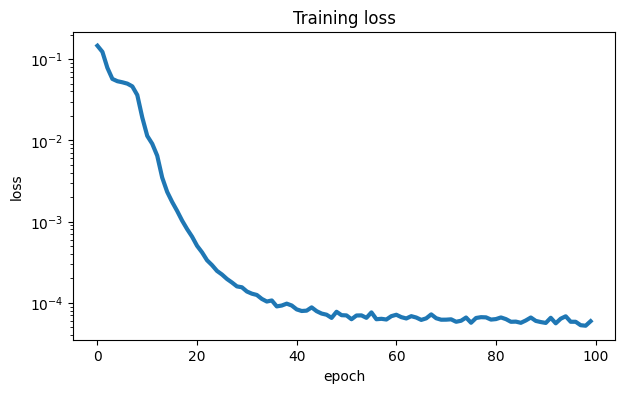

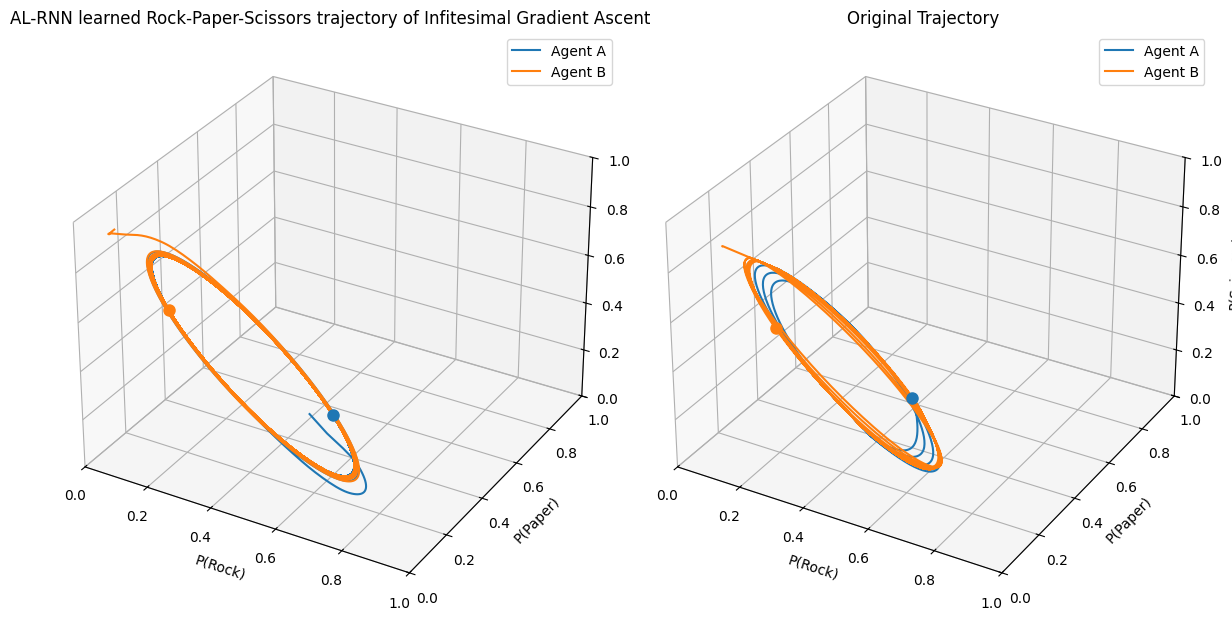

Saving trained model models/2026-05-13 08:05:38Rock-Paper-Scissors_Infitesimal Gradient Ascent


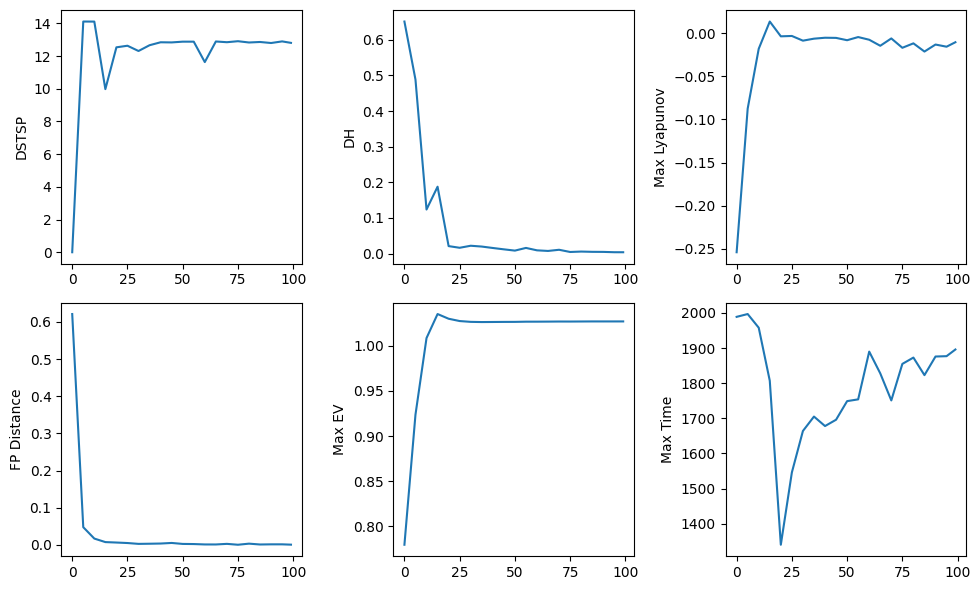

In [19]:
rps_gameData = gamesData[0]
iga_data = rps_gameData.trajectory_data[0]
iga_data.model = create_model(iga_data.trajectory)
iga_log_path = train_and_save_model(rps_gameData, iga_data)
visualize_training(iga_log_path)

From left to right, top to bottom, we have:
- DSTSP = state space distance based on the Kullback-Leibler (KL) divergence
- DH = Hellinger distances (DH) between the power spectra 
of the true and generated time series
- Max Lyapunov Exponent (how much trajectories between two initial points)
- FP Distance: The Distance between the fixed points of the learned model's first N readout neurons and the actual fixed points of the reward matrix ($(1/3, 1/3, 1/3, 1/3)^T$ in the case of RPS)
- Max EV: The maximum absolute eigenvalue of any region, informing us about the stability of that region's FP.
- Max Time: The maximum amount of time steps spent in a single region - e.g. if the model spends 1500 time steps in one region and 500 in another, this tracks the 1500. The trajectories themselves are generated on 2000 time steps.

N: 4, M: 12, P: 3
Training AL-RNN for trajectory generated with Wolf PHC for game Rock-Paper-Scissors


Training Progress: 100%|███████| 100/100 [01:05<00:00,  1.52it/s, loss=0.000521]


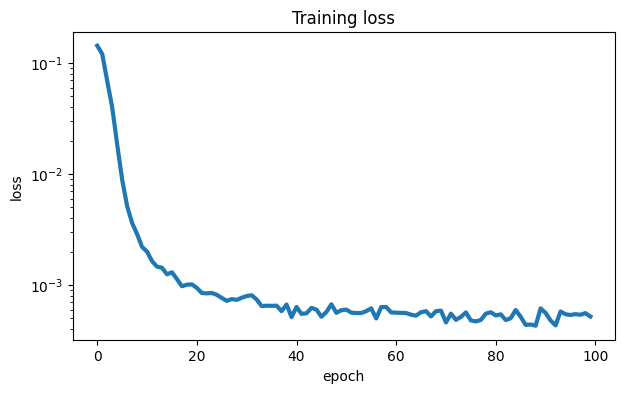

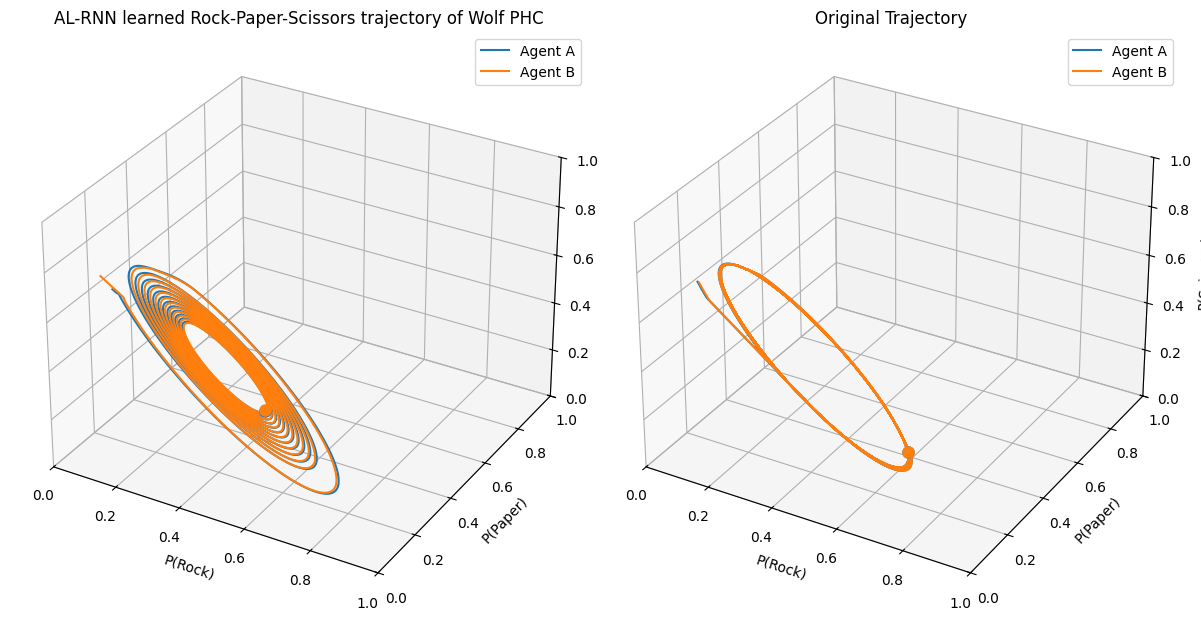

Saving trained model models/2026-05-13 08:06:44Rock-Paper-Scissors_Wolf PHC


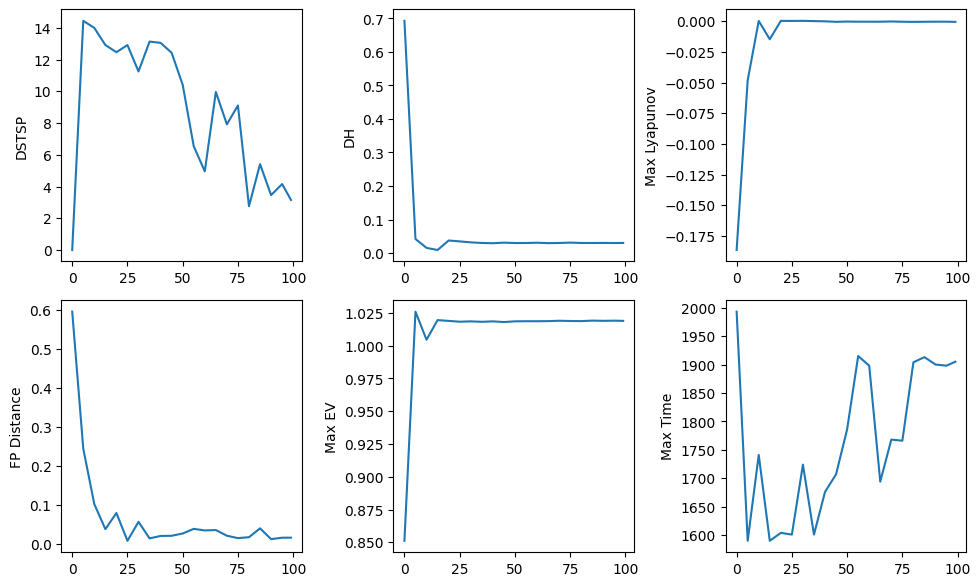

In [20]:
wolf_phc_data = rps_gameData.trajectory_data[1]
wolf_phc_data.model = create_model(wolf_phc_data.trajectory)
wolf_phc_log_path = train_and_save_model(rps_gameData, wolf_phc_data)
visualize_training(wolf_phc_log_path)

What is interesting about the above data is that despite the original Wolf-PHC trajectory orbiting instead of spiraling, the learned trajectory spirals inward. According to p. 149 in the MARL book, Wolf-PHC is supposed to yield a spiral, so my implementation may just be broken. It is interesting nonetheless because this may indicate that the AL-RNN captures the spiraling dynamic steadily and easily even though it is not apparent visually. I've tried increasing the timesteps in Wolf-PHC, but the trajectory keeps orbiting instead of spiraling inward.

N: 4, M: 12, P: 3
Training AL-RNN for trajectory generated with Regret Matching for game Rock-Paper-Scissors


Training Progress: 100%|████████| 100/100 [01:04<00:00,  1.56it/s, loss=0.00874]


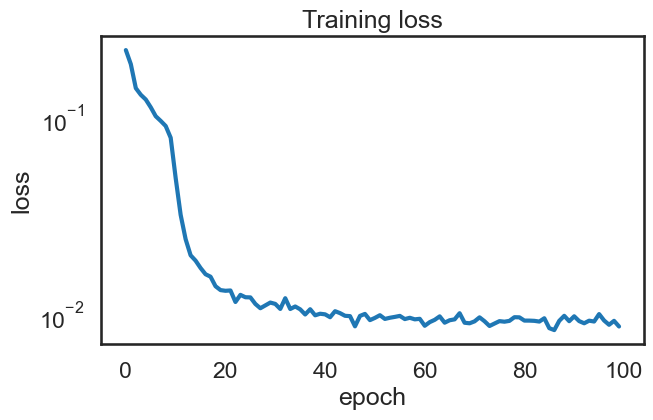

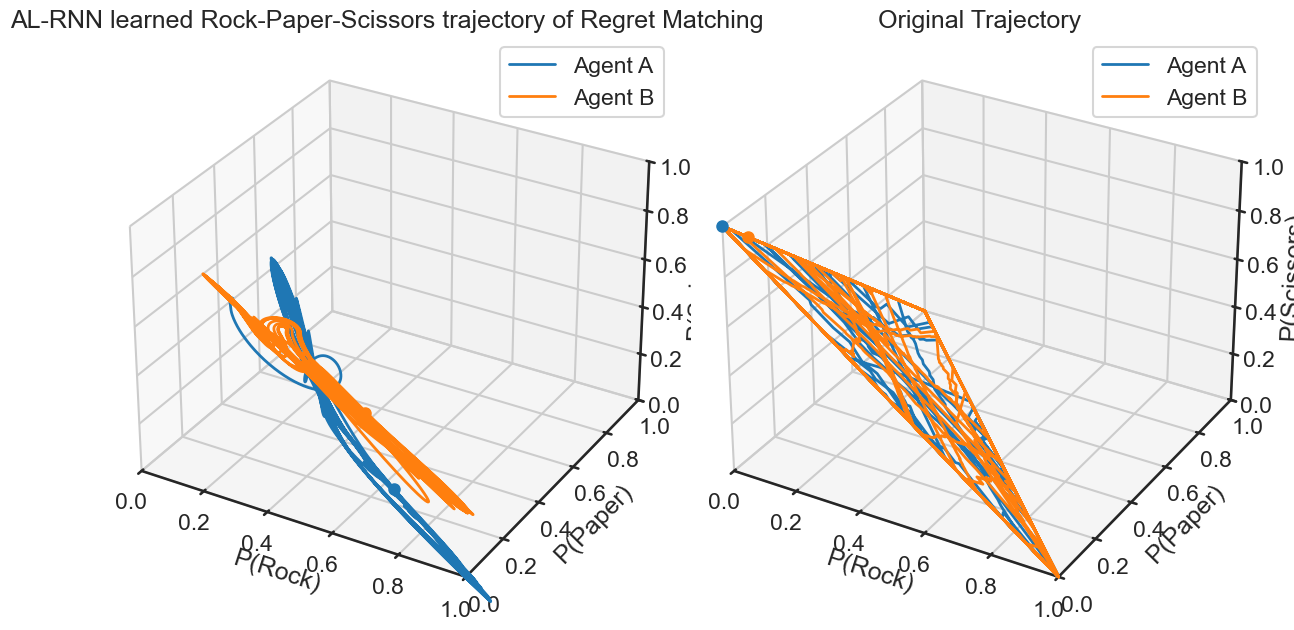

Saving trained model models/2026-05-13 08:14:25Rock-Paper-Scissors_Regret Matching


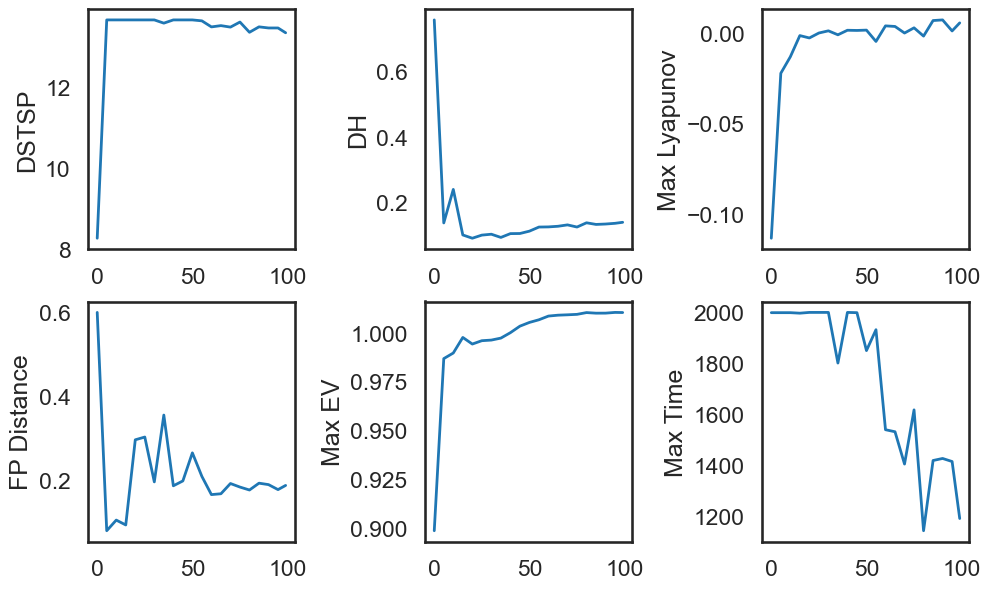

In [32]:
rm_data = rps_gameData.trajectory_data[2]
rm_data.model = create_model(rm_data.trajectory)
rm_log_path = train_and_save_model(rps_gameData, rm_data)
visualize_training(rm_log_path)

The model's loss after 100 epochs is the highest of all trained models. The learned trajectory for Regret Matching resembles something like a wild orbit. It isn't cleanly circular or oval, but it does seem to center close to the fixed point. Let's look at what the actual FP of the model is in each region:

In [33]:
rm_bits = lrf.convert_to_bits(rm_data.generated_trajectory[:,-rm_data.model.P:].detach().numpy()) #sequence of current active subregion, encoded in bits
_, rm_regions = lrf.unique_regions_crossed(rm_bits, rm_data.model.M)
print(calc_FP(rm_data.model, rm_regions))

(array([[ 0.90046555,  0.04041332,  0.2421518 ,  0.35197532, -0.53024316,
        -0.42875117, -0.03413428,  0.12812982,  0.1837796 ,  0.07219867,
         0.1499498 ,  0.00853929],
       [ 0.30926666,  0.38243338,  0.5101828 ,  0.3517654 , -0.3548103 ,
        -0.4147898 , -0.24532747,  0.21844147,  0.339668  , -0.08099446,
         0.37497982,  0.1285412 ],
       [ 0.9092348 ,  0.02941987,  0.20429167,  0.34981167, -0.53242254,
        -0.4189869 , -0.01898694,  0.11781093,  0.17324847,  0.07915686,
         0.12470446, -0.00191134]], dtype=float32), [1.0103211402893066, 1.0022883415222168, 1.003289818763733])


The second FP is the one closest to $(1/3, 1/3, 1/3, 1/3)^T$, but still farther away from it than the FPs of the other models.

### Analysis
We look at some of the analysis done in the original AL-RNN paper, mostly re-using their code on our models.

In [23]:
import seaborn as sns
from scipy import optimize
import itertools
from collections import Counter
from matplotlib.colors import Normalize

In [24]:
def compare_metrics(model, X_test):
    X_test_torch = torch.tensor(X_test[:], dtype=torch.float32).unsqueeze(0)
    T_gen=int(X_test_torch.shape[1]) # Sequence length
    T_r=int(T_gen / 10) # Transient cutoff length
    orbit=predict_free_sequence(model, X_test_torch[0],T_gen+T_r).detach().numpy()[0][T_r:,:] # Predict a sequence
    #orbit=generate_trajectory(model, X_test_dataset, T_gen+T_r)
    print(orbit.shape)
    Dstsp = state_space_divergence_binning(torch.tensor(orbit[:,0:model.N]), X_test_torch[0,:,:])
    DH = power_spectrum_error(torch.tensor(orbit[:,0:model.N]), X_test_torch[0,0:T_gen,:])
    print("State space distance (Dstsp): ", Dstsp)
    print("Hellinger Distance (DH): ", DH)
    return orbit, T_gen

def compare_orbits(X_test, orbit, T_gen):
    Blues = plt.cm.Blues
    plt.rcParams["lines.linewidth"] = .35
    plt.rcParams["figure.figsize"] = (7,5)
    plt.rcParams["lines.linewidth"] = 2.
    plt.rcParams.update({'font.size': 10})
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    a_x = orbit[:, 0]
    a_y = orbit[:, 1]
    ax.plot(X_test[:T_gen, 0], X_test[:T_gen, 1], color=Blues (0.9), label="Ground Truth")
    ax.plot(a_x, a_y, color=Blues (0.6), alpha=1., label="Freely Generated")
    
    plt.legend(loc="upper left")
    
    plt.axis("off")
    plt.show()

    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    b_x = orbit[:, 2]
    b_y = orbit[:, 3]
    ax.plot(X_test[:T_gen, 2], X_test[:T_gen, 3], color=Blues (0.9), label="Ground Truth")
    ax.plot(b_x, b_y, color=Blues (0.6), alpha=1., label="Freely Generated")
    
    plt.legend(loc="upper left")
    
    plt.axis("off")
    plt.show()


def compare_subregions(orbit, model):
    generated_latent=orbit[:,-model.P:] #latent sequence in PWL units
    generated_observations=orbit[:,:model.N] #predicted readout sequence 
    
    bits = lrf.convert_to_bits(generated_latent) #sequence of current active subregion, encoded in bits
    regions, unique_regions = lrf.unique_regions_crossed(bits, model.M) #Number of linear subregions, used linear subregions encoded as bits
    frequencies=lrf.frequency_of_regions(bits,unique_regions) #How often is each subregion visited

    print("Unique regions:")
    print(unique_regions)

    print("Frequencies:")
    print(frequencies)

    #crossings = [''.join(map(str, e)) for e in lrf.boundary_crossings_optimized(bits)]
    #if len(crossings) > 0:
        #print("Cycle identified:")
        #print(identify_cycle(crossings))
    #else:
        #print("No crossings")

    print("FPs:")
    fixed_points, max_evs = calc_FP(model, unique_regions)
    print(fixed_points)
    print("Max EVs:")
    print(max_evs)

    mle = max_lyapunov_exponent(model, orbit, 100)
    print("Max Lyapunov Exponent:")
    print(mle)
    
    #Compute order of most freqnent visited subregions
    frequency_list = np.copy(frequencies)
    regions_list = np.copy(unique_regions)    
    most_frequent_regions = []
    for _ in range(len(frequency_list)):
        index = np.argmax(frequency_list)
        most_frequent_regions.append(regions_list[index])
        frequency_list = np.delete(frequency_list, index)
        regions_list = np.delete(regions_list, index, axis=0)
    connectome = lrf.connectome_with_self_connections(bits, most_frequent_regions, len(most_frequent_regions))
    print("Used subregions:",len(connectome))
    print("Timesteps in subregion:",frequencies)
    plt.figure(figsize=(7, 5))
    sns.set_context('talk', font_scale=1.2) 
    sns.set_style('white')
    
    # Define a custom diverging colormap with higher contrast
    #cmap = sns.diverging_palette(220, 20, as_cmap=True)
    cmap = plt.get_cmap('Blues')
    
    # Plot the heatmap with selected improvements
    ax = sns.heatmap(data=connectome[:, :], annot=False, linewidths=0, cmap=cmap, square=True,
                     yticklabels=False, xticklabels=False, cbar_kws={'label': 'Transition Probability'})
    
    # Rotate the colorbar label for better visibility
    cbar = ax.collections[0].colorbar
    cbar.set_label('Transition Probability', rotation=270, labelpad=35)
    
    # Optionally, adjust the limits of the color map to enhance contrast
    ax.collections[0].set_clim(0, np.max(connectome)-0.015)
    
    plt.show()
    return generated_observations, generated_latent

def visualize_regions(model, generated_observations, generated_latent):
    sns.set_context('talk', font_scale=1.0) 
    plt.rcParams["lines.linewidth"] = 2.
    
    observations_plot = generated_observations[:, :model.N]
    bitcode_plot = lrf.convert_to_bits(generated_latent)
    
    # Convert bitcode arrays to strings
    bitcodes_str = [''.join(map(str, map(int, b))) for b in bitcode_plot]
    
    # Count the frequency of each bitcode
    bitcode_freq = Counter(bitcodes_str)
    most_frequent_regions = [item[0] for item in bitcode_freq.most_common()]
    frequency_order_map = {code: idx for idx, code in enumerate(most_frequent_regions)}
    order = [frequency_order_map[code] for code in bitcodes_str]
    
    # Normalize order indices for color mapping
    order_array = np.array(order)
    norm = Normalize(vmin=order_array.min(), vmax=order_array.max())
    cmap = plt.get_cmap('cividis')
    colors = cmap(norm(order_array))

    n = 2000 #observations_plot.shape[0] - 1
    
    # Plot data for Agent A
    fig = plt.figure(figsize=(10, 8))
    #fig.tight_layout()
    ax = fig.add_subplot(221, projection='3d')
    p_third_option_a = 1 - observations_plot[:, 0] - observations_plot[:, 1]
    scatter = ax.scatter(observations_plot[:, 0], observations_plot[:, 1], p_third_option_a, c=colors, s=220)
    xLabel = 'P(Rock) A'
    yLabel = 'P(Paper) A'
    zLabel = 'P(Scissors) A'
    ax.set_xlabel(xLabel)
    ax.set_ylabel(yLabel)
    ax.set_zlabel(zLabel)
    ax.axis("off")
    
    ax = fig.add_subplot(322)
    for i in range(n):
        ax.plot([i, i+1], [observations_plot[i, 0], observations_plot[i+1, 0]], color=colors[i+1])
    ax.set_ylabel(xLabel)
    
    ax = fig.add_subplot(324)
    for i in range(n):
        ax.plot([i, i+1], [observations_plot[i, 1], observations_plot[i+1, 1]], color=colors[i+1])
    ax.set_ylabel(yLabel)
    
    ax = fig.add_subplot(326)
    for i in range(n):
        ax.plot([i, i+1], [p_third_option_a[i], p_third_option_a[i+1]], color=colors[i+1])
    ax.set_ylabel(zLabel)
    #plt.tight_layout()
    plt.show()

    # Plot data for Agent B
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(221, projection='3d')
    p_third_option_b = 1 - observations_plot[:, 2] - observations_plot[:, 3]
    scatter = ax.scatter(observations_plot[:, 2], observations_plot[:, 3], p_third_option_b, c=colors, s=220)
    xLabel = 'P(Rock) B'
    yLabel = 'P(Paper) B'
    zLabel = 'P(Scissors) B'
    ax.set_xlabel(xLabel)
    ax.set_ylabel(yLabel)
    ax.set_zlabel(zLabel)
    ax.axis("off")
    
    ax = fig.add_subplot(322)
    for i in range(n):
        ax.plot([i, i+1], [observations_plot[i, 2], observations_plot[i+1, 2]], color=colors[i+1])
    ax.set_ylabel(xLabel)
    
    ax = fig.add_subplot(324)
    for i in range(n):
        ax.plot([i, i+1], [observations_plot[i, 3], observations_plot[i+1, 3]], color=colors[i+1])
    ax.set_ylabel(yLabel)

    ax = fig.add_subplot(326)
    for i in range(n):
        ax.plot([i, i+1], [p_third_option_b[i], p_third_option_b[i+1]], color=colors[i+1])
    ax.set_ylabel(yLabel)
    
    #plt.tight_layout()
    plt.show()

def show_comparison(gameData, test_trajectory_data, trajectory_data):
    print(trajectory_data.algo_name)
    orbit, T_gen = compare_metrics(trajectory_data.model, trajectory_data.trajectory)
    compare_orbits(test_trajectory_data.trajectory, orbit, T_gen)
    generated_observations, generated_latent = compare_subregions(orbit, trajectory_data.model)
    visualize_regions(trajectory_data.model, generated_observations, generated_latent)

In [25]:
[test_traj_iga, test_traj_wolf, test_traj_rm] = generate_trajectories(rps_gameData)

Infitesimal Gradient Ascent
(8000, 12)
State space distance (Dstsp):  13.637435913085938
Hellinger Distance (DH):  0.008546161


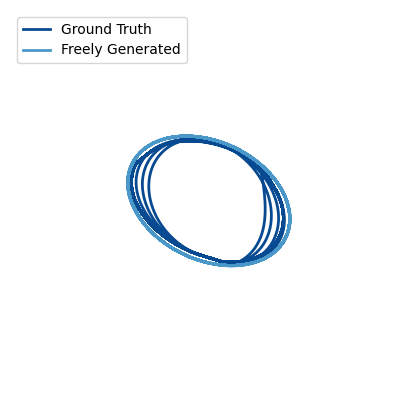

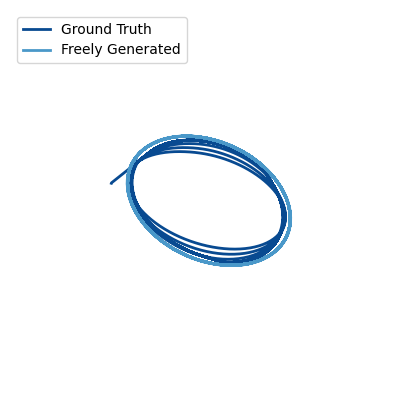

Unique regions:
[[0 1 1]
 [0 1 0]]
Frequencies:
[7847  153]
FPs:
[[ 0.33297437  0.33357447  0.33347458  0.33317643  0.21256888 -0.05308205
   0.12920181  0.11445753 -0.1578151  -0.18126228  0.28174168  0.41312116]
 [ 1.0010763  -0.06414675 -0.16215098  0.9034749  -0.6149701  -0.5332699
   0.25054285  0.35376474 -0.8587675   0.07480423  0.44558385 -0.14831483]]
Max EVs:
[1.0000017881393433, 1.0269848108291626]
Max Lyapunov Exponent:
-0.0038014152710456983
Used subregions: 2
Timesteps in subregion: [7847  153]


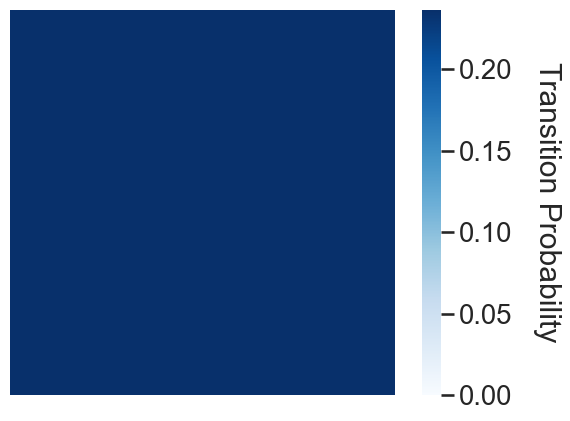

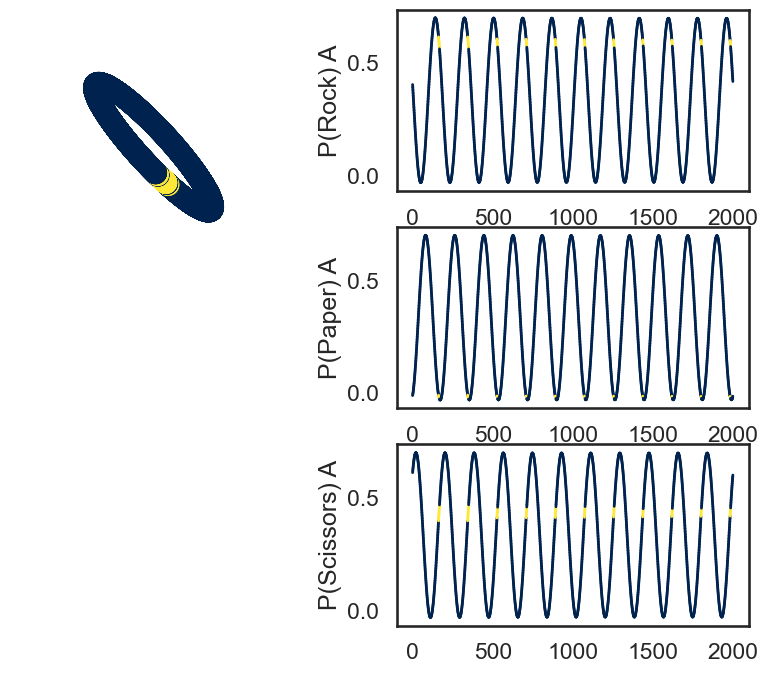

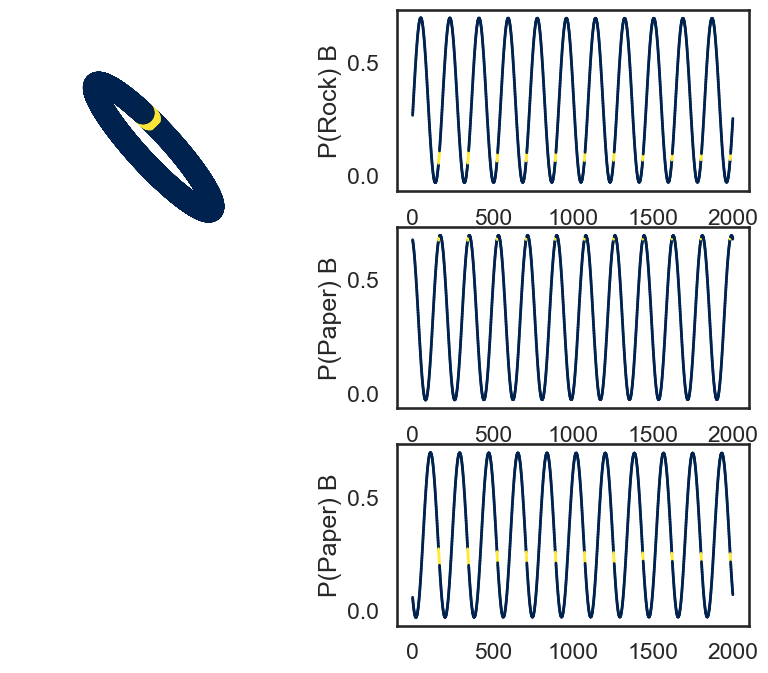

In [26]:
show_comparison(rps_gameData, test_traj_iga, iga_data)

Wolf PHC
(8000, 12)
State space distance (Dstsp):  7.463738441467285
Hellinger Distance (DH):  0.022261366


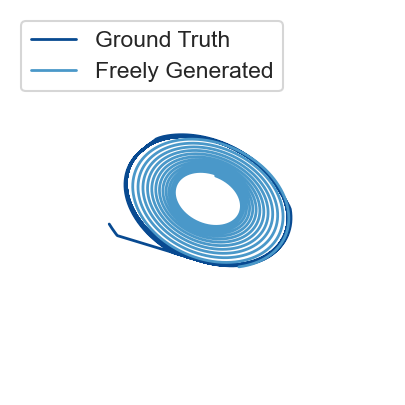

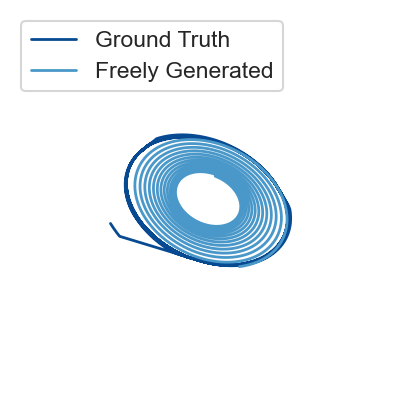

Unique regions:
[[1 1 0]]
Frequencies:
[8000]
FPs:
[[ 0.34399572  0.33051804  0.3452736   0.33103782  0.02043626 -0.2593258
   0.1331083   0.1789642   0.02927268  0.27331725  0.20455799 -0.12504765]]
Max EVs:
[0.9998867511749268]
Max Lyapunov Exponent:
-0.0004329795575245043
Used subregions: 1
Timesteps in subregion: [8000]


/Users/user/projects/alrnn-marl/linear_region_functions.py:107: RuntimeWarning: invalid value encountered in divide
  conn /= np.sum(conn)
/opt/anaconda3/envs/marl-alrnn/lib/python3.12/site-packages/seaborn/matrix.py:202: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(calc_data)
/opt/anaconda3/envs/marl-alrnn/lib/python3.12/site-packages/seaborn/matrix.py:207: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(calc_data)


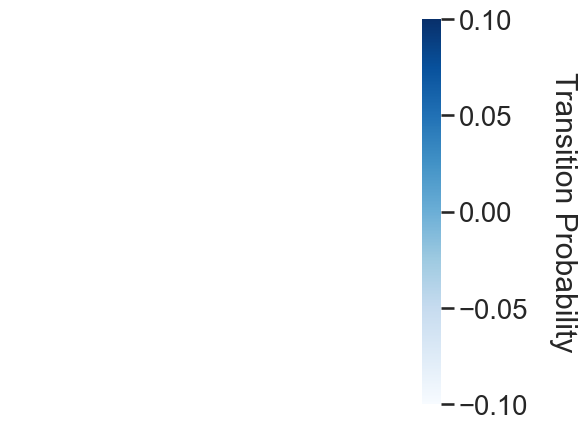

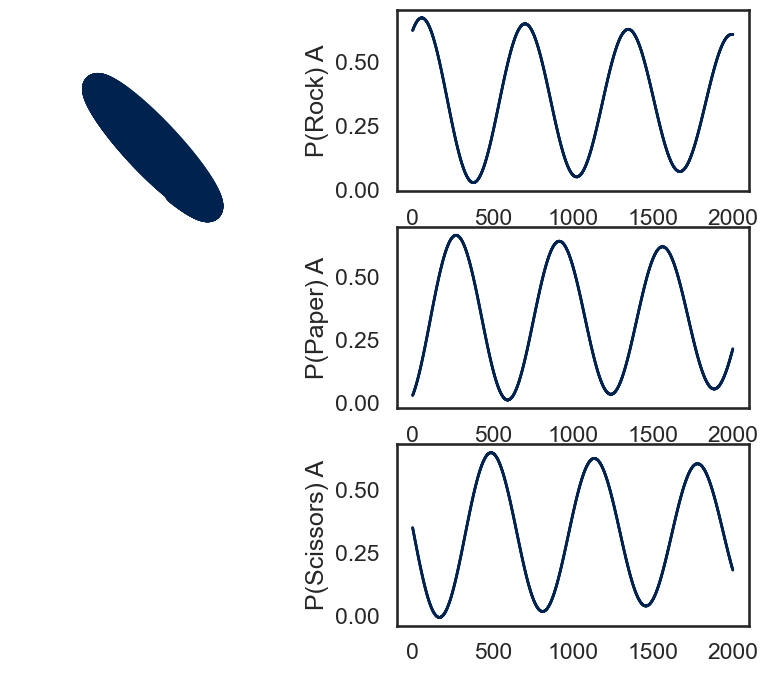

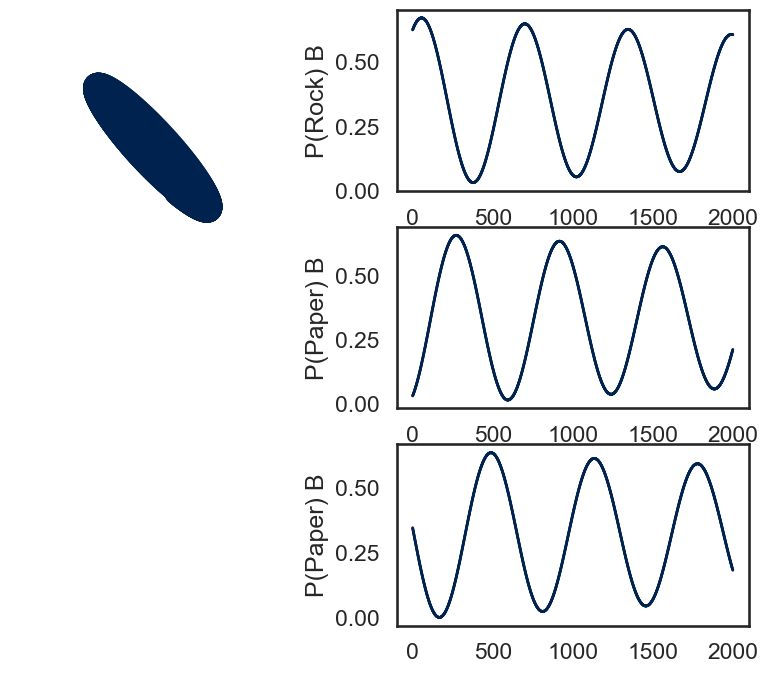

In [27]:
show_comparison(rps_gameData, test_traj_wolf, wolf_phc_data)

Regret Matching
(8000, 12)
State space distance (Dstsp):  15.044548034667969
Hellinger Distance (DH):  0.08289282


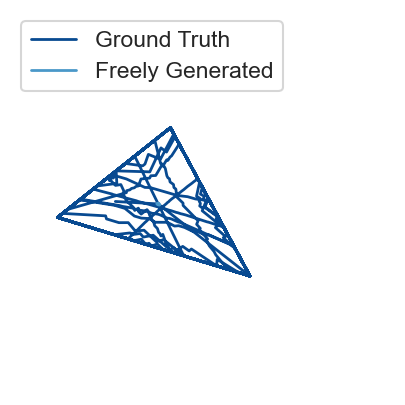

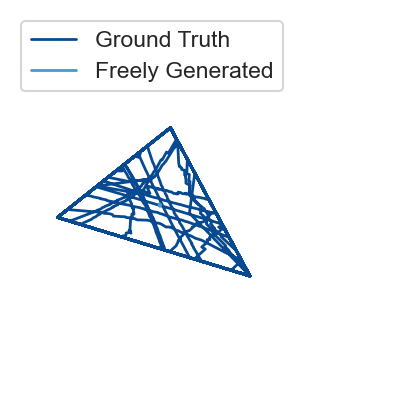

Unique regions:
[[1 0 1]]
Frequencies:
[8000]
FPs:
[[ 0.3345772   0.33356476  0.34600616  0.32564187 -0.07209611 -0.06328553
  -0.07455814  0.01660496 -0.0297066   0.1387379  -0.35584873  0.36450154]]
Max EVs:
[0.9965108633041382]
Max Lyapunov Exponent:
-0.00425800446420908
Used subregions: 1
Timesteps in subregion: [8000]


/Users/user/projects/alrnn-marl/linear_region_functions.py:107: RuntimeWarning: invalid value encountered in divide
  conn /= np.sum(conn)
/opt/anaconda3/envs/marl-alrnn/lib/python3.12/site-packages/seaborn/matrix.py:202: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(calc_data)
/opt/anaconda3/envs/marl-alrnn/lib/python3.12/site-packages/seaborn/matrix.py:207: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(calc_data)


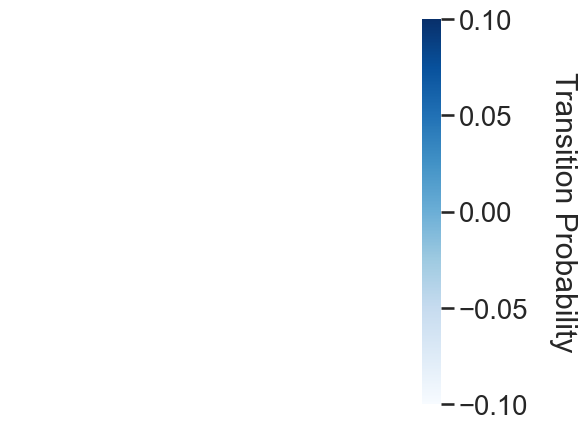

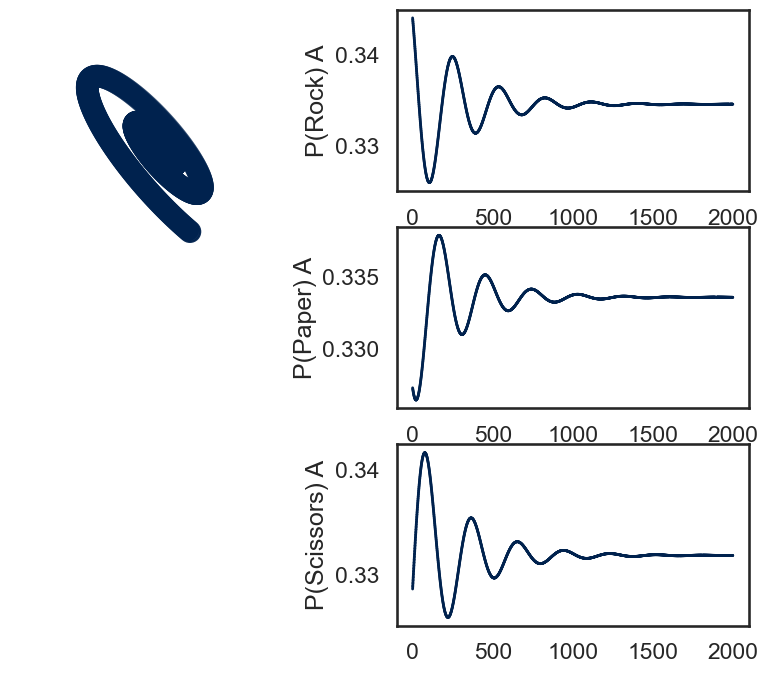

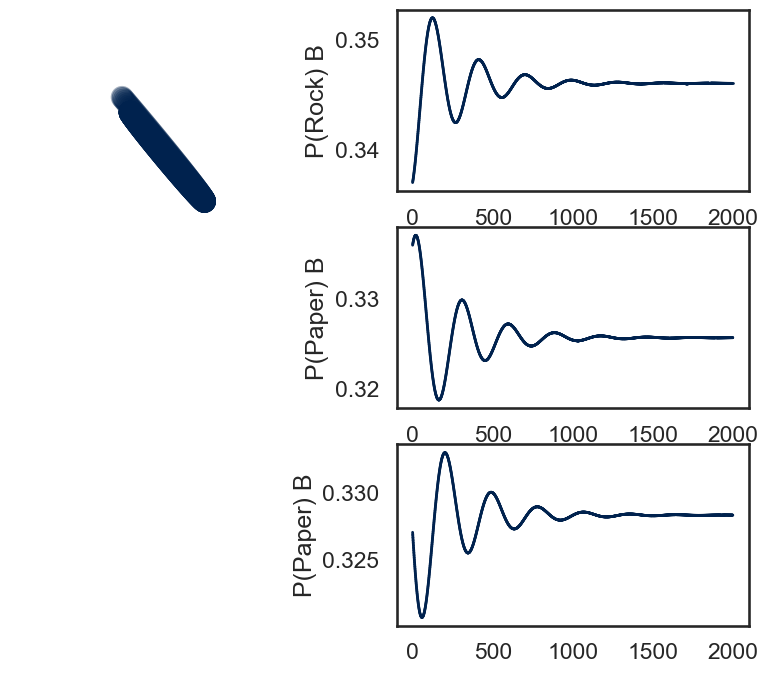

In [28]:
show_comparison(rps_gameData, test_traj_rm, rm_data)